<a href="https://colab.research.google.com/github/asegura4488/EDCO_MachineLearning/blob/main/Semana2/RegresionLineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:

from google.colab import drive
from google.colab import files
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [22]:
# Necesitamos explorar la estructura de directorios
import os
# Necesito ir a la carpeta del curso
os.chdir('/content/drive/MyDrive/EDCO_MachineLearning/Semana2/')

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [24]:
# Problemas de regresion
data = pd.read_csv('Datos/DatosRegresion.csv')
data

,X0,X1,Y
0,5.488135,6.207617,25.523276
1,7.151894,7.460697,32.167177
2,6.027634,10.499409,43.066154
3,5.448832,15.011900,38.069097
4,4.236548,6.670149,21.101511
...,...,...,...
495,2.716528,1.953527,5.693810
496,4.554441,10.298444,28.084859
497,4.017135,18.768240,51.312559
498,2.484135,4.572931,18.596668


In [25]:
X = np.array(data[['X0','X1']])
Y = np.array(data['Y'])

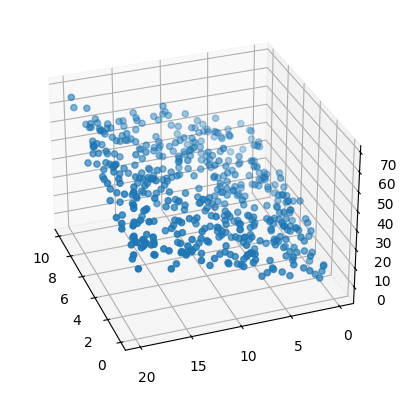

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d', elev=30, azim=160)
ax.scatter(X[:,0], X[:,1], Y)
plt.show()

In [27]:
# EL espacio de datos parece ser un plano en el espacio que relaciona
# las variables X0, X1 con Y

In [28]:
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=42)
# No tenemos estratificacion en los datos

In [29]:
# Modelo
Model = LinearRegression()
Model.fit(XTrain, YTrain)

LinearRegression()

In [30]:
Model.intercept_

np.float64(3.770760603399548)

In [31]:
Model.coef_[0]

np.float64(2.4738169495486084)

In [32]:
Model.coef_[1]

np.float64(1.4807416623384977)

In [33]:
params = np.array([Model.intercept_,Model.coef_[0],Model.coef_[1]])
params

array([3.7707606 , 2.47381695, 1.48074166])

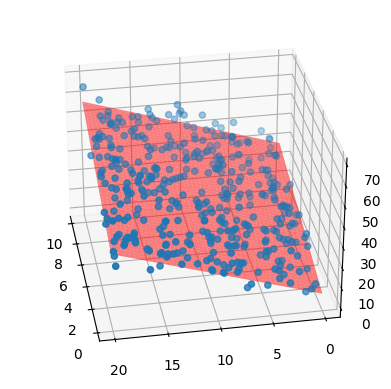

In [34]:
# Vamos a pintar el modelo, quiero intuicion geometrica
x0 = np.linspace(min(XTrain[:,0]), max(XTrain[:,0]), 100)
x1 = np.linspace(min(XTrain[:,1]), max(XTrain[:,1]), 100)
xx0, xx1 = np.meshgrid(x0,x1)

Ygrid = params[0] + params[1]*xx0 + params[2]*xx1 # La ecuacion del modelo, es un plano

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d', elev=30, azim=170)
ax.scatter(XTrain[:,0], XTrain[:,1], YTrain)
ax.plot_surface(xx0, xx1, Ygrid, alpha=0.5, color='r')
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7fe5180b6960>,
 'caps': [<matplotlib.lines.Line2D at 0x7fe5180b6f60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fe5180b6660>],
 'medians': [<matplotlib.lines.Line2D at 0x7fe5180b7500>],
 'fliers': [<matplotlib.lines.Line2D at 0x7fe5180b77a0>],
 'means': []}

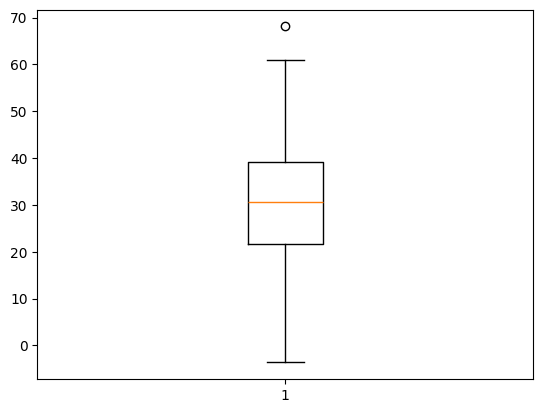

In [35]:
plt.boxplot(Y)

In [51]:
# Necesitamos metricas para la regresion
mean_squared_error(Model.predict(XTest), YTest)

25.12949710404716

In [37]:
mean_absolute_error(Model.predict(XTest), YTest)

3.9662708992995794

In [38]:
r2_score(Model.predict(XTest), YTest)

0.8180271789203662

In [53]:
# La matriz generadora del espacio columna
A = np.ones((XTrain.shape[0],3))
A[:,1] = XTrain[:,0]
A[:,2] = XTrain[:,1]
A

array([[ 1.        ,  4.88056281, 10.15271094],
       [ 1.        ,  6.65859118,  1.99465894],
       [ 1.        ,  8.70012148, 17.58469526],
       ...,
       [ 1.        ,  5.77542949,  7.47022028],
       [ 1.        ,  4.24088988, 16.40044872],
       [ 1.        ,  7.35194022, 13.60697332]])

In [54]:
A.shape

(400, 3)

In [59]:
b = np.array(YTrain)

In [60]:
# QUeremos encontrar las proyeccion ortogonal de la columna (Variables explicativas)
# sobre el vector columna (Variable dependiente)

In [61]:
AT = np.dot(A.T,A)
AT

array([[  400.        ,  2052.6277061 ,  4034.00502821],
       [ 2052.6277061 , 13994.63110774, 20351.30116437],
       [ 4034.00502821, 20351.30116437, 53775.15150333]])

In [62]:
bT = np.dot(A.T,b)
bT

array([ 12559.44876318,  72495.14284151, 145183.7682296 ])

In [63]:
# Pensemos en la solución
params1 = np.linalg.solve(AT,bT)
params1

array([3.7707606 , 2.47381695, 1.48074166])

In [64]:
params

array([3.7707606 , 2.47381695, 1.48074166])